In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from pathlib import Path
import numpy as np

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [29]:
df_orders_items = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/order_items.csv")
df_products = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/products.csv")
df_sales =  pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/sales.csv')
df_customers = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/customers.csv')
df_orders = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/orders.csv')
df_payments = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/payments.csv')
df_returns = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/returns.csv')
df_shipments = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/shipments.csv')
df_reviews = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/reviews.csv')
df_promotions = pd.read_csv('/home/ducvu0904/Downloads/Datathon/data/promotions.csv')

/tmp/ipykernel_135163/2884446620.py:1: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orders_items = pd.read_csv("/home/ducvu0904/Downloads/Datathon/data/order_items.csv")


# Revenue Timeline (Forecasting Foundation)

## Overview
Phân tích doanh thu theo thời gian nhằm phục vụ forecasting, tập trung vào xu hướng, tính chu kỳ và biên lợi nhuận.


### Graph 1 - Revenue vs Gross Margin Trend

Biểu đồ gồm hai phần theo thời gian: doanh thu MA 30 ngày ở phía trên và biên lợi nhuận gộp MA 30 ngày ở phía dưới.
Mục tiêu là quan sát xu hướng tăng trưởng doanh thu đi cùng sự ổn định hoặc biến động của margin theo từng giai đoạn.

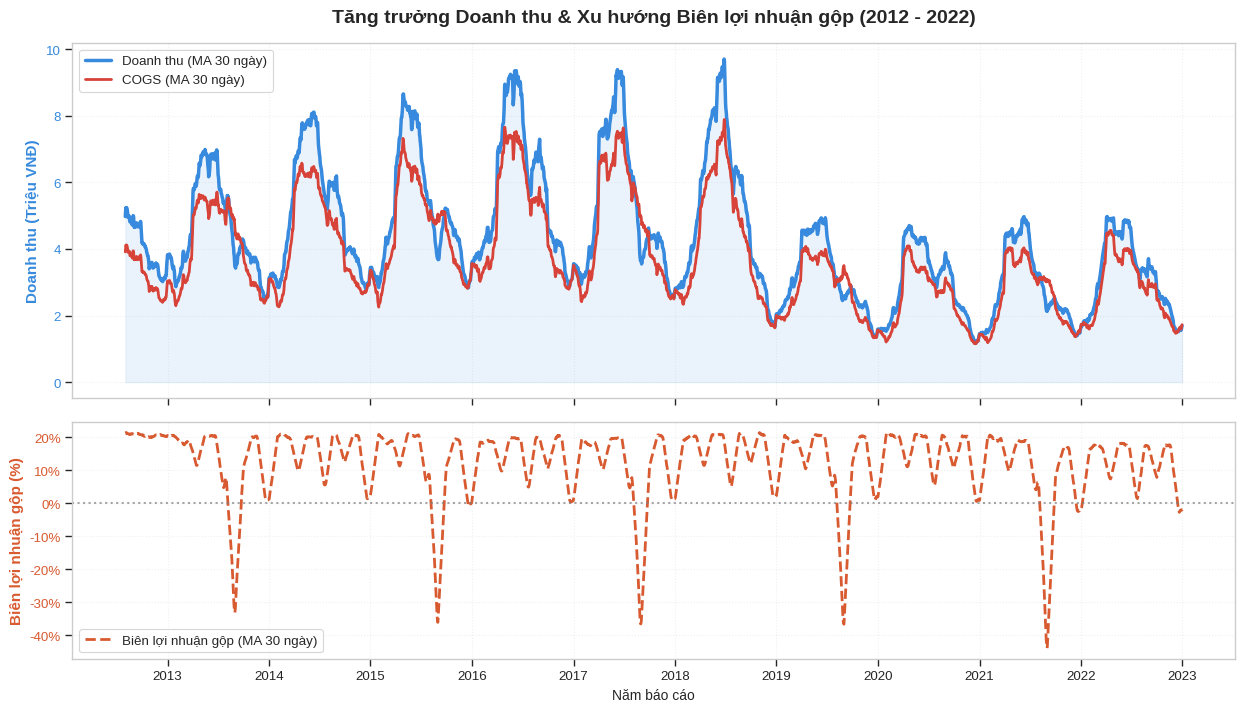

In [30]:
# 1. Tiền xử lý tính toán
df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')
df_sales = df_sales.sort_values('Date')
df_sales['Revenue_mil'] = df_sales['Revenue'] / 1_000_000
df_sales['rev_smooth_mil'] = df_sales['Revenue_mil'].rolling(30).mean()

df_sales['COGS_mil'] = df_sales['COGS'] / 1_000_000
df_sales['cogs_smooth_mil'] = df_sales['COGS_mil'].rolling(30).mean()

df_sales['margin'] = (df_sales['Revenue'] - df_sales['COGS']) / df_sales['Revenue']
df_sales['margin_smooth'] = df_sales['margin'].rolling(30).mean()

# 2. Khởi tạo Figure với 2 subplots (2 hàng, 1 cột), chia sẻ chung trục X
# Tỷ lệ chiều cao 1.5 : 1 để ưu tiên không gian cho Revenue
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [1.5, 1]})
plt.subplots_adjust(hspace=0.08) 

# --- NỬA TRÊN: Revenue (ax1) ---
ax1.plot(df_sales['Date'], df_sales['rev_smooth_mil'], color='#378ADD', lw=2.5, label='Doanh thu (MA 30 ngày)')
ax1.fill_between(df_sales['Date'], df_sales['rev_smooth_mil'], alpha=0.1, color='#378ADD')
ax1.plot(df_sales['Date'], df_sales['cogs_smooth_mil'], color='#D84339', lw=2.0, label='COGS (MA 30 ngày)')
ax1.set_ylabel("Doanh thu (Triệu VNĐ)", color='#378ADD', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#378ADD')
ax1.set_title("Tăng trưởng Doanh thu & Xu hướng Biên lợi nhuận gộp (2012 - 2022)", 
              fontsize=14, pad=15, fontweight='bold')

ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3, linestyle=':')

# --- NỬA DƯỚI: Gross Margin (ax2) ---
ax2.plot(df_sales['Date'], df_sales['margin_smooth'], color='#D85A30', lw=2,
         linestyle='--', label='Biên lợi nhuận gộp (MA 30 ngày)')
ax2.set_ylabel("Biên lợi nhuận gộp (%)", color='#D85A30', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Vẽ đường baseline 0%
ax2.axhline(0, color='gray', linestyle=':', lw=1.5, alpha=0.7)

ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, alpha=0.3, linestyle=':')

# --- Định dạng trục X (Chỉ cần set ở ax2 vì đã sharex=True) ---
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlabel("Năm báo cáo", fontsize=10)
plt.xticks(rotation=0)

plt.show()

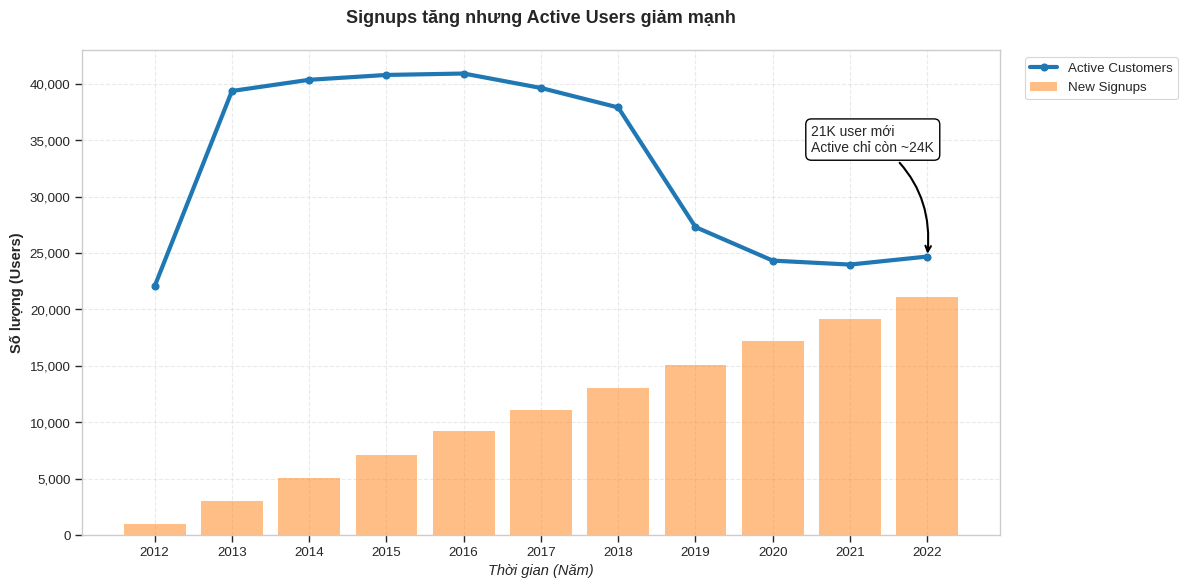

In [31]:
# ==============================================================================
# BƯỚC 2: DIAGNOSTIC DATA PREP
# ==============================================================================
orders_df = df_orders.copy()
customers_df = df_customers.copy()

orders_df.columns = orders_df.columns.str.strip()
customers_df.columns = customers_df.columns.str.strip()

orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['year'] = orders_df['order_date'].dt.year
customers_df['signup_date'] = pd.to_datetime(customers_df['signup_date'])
customers_df['signup_year'] = customers_df['signup_date'].dt.year

active_cust = orders_df.groupby('year')['customer_id'].nunique().reset_index(name='active_customers')
new_cust = customers_df.groupby('signup_year').size().reset_index(name='new_customers')

user_health = active_cust.merge(new_cust, left_on='year', right_on='signup_year', how='inner')

# ==============================================================================
# PLOT 2: CLEAN VERSION
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# --- GRID xuống dưới ---
ax.set_axisbelow(True)
ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.4, zorder=0)

# Line
ax.plot(
    user_health['year'],
    user_health['active_customers'],
    color='#1f77b4',
    linewidth=3,
    marker='o',
    label='Active Customers',
    zorder=3
)

# Bar
ax.bar(
    user_health['year'],
    user_health['new_customers'],
    color='#ff7f0e',
    alpha=0.5,
    label='New Signups',
    zorder=2
)

# Axis
ax.set_ylabel('Số lượng (Users)', fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.set_xlabel('Thời gian (Năm)', style='italic')
ax.set_xticks(user_health['year'])

# Legend
ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

# Title
plt.title(
    'Signups tăng nhưng Active Users giảm mạnh',
    fontsize=13,
    fontweight='bold',
    pad=20
)

# --- FIX ANNOTATION TRIỆT ĐỂ ---
ax.annotate(
    '21K user mới\nActive chỉ còn ~24K',
    xy=(2022, 24696),
    xytext=(2020.5, 34000),  # đẩy lên vùng trống phía trên
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5,
        connectionstyle="arc3,rad=-0.3"  # mũi tên cong tránh line
    ),
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="black",
        lw=1
    ),
    zorder=4
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'leaky_bucket_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# --- PREP ---
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_customers['signup_year'] = df_customers['signup_date'].dt.year

paid_channels = {'paid_search', 'social_media'}  # dùng set để lookup O(1)

df_customers['channel_type'] = np.where(
    df_customers['acquisition_channel'].isin(paid_channels),
    'Paid (Tốn phí)',
    'Organic/Other (Miễn phí)'
)

# --- AGG ---
channel_trend = (
    df_customers
    .groupby(['signup_year', 'channel_type'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# --- COMPUTE RATIO ---
channel_trend['total'] = channel_trend.sum(axis=1)
channel_trend['paid_pct'] = (
    channel_trend.get('Paid (Tốn phí)', 0) / channel_trend['total'] * 100
)

# --- PRINT (loop, không hardcode năm) ---
for year, row in channel_trend.iterrows():
    paid = row.get('Paid (Tốn phí)', 0)
    total = row['total']
    pct = row['paid_pct']
    print(f"Năm {int(year)}, có {paid:,.0f} user ({pct:.1f}%) đến từ kênh Trả phí.")

Năm 2012, có 408 user (42.6%) đến từ kênh Trả phí.
Năm 2013, có 1,177 user (39.4%) đến từ kênh Trả phí.
Năm 2014, có 1,973 user (39.2%) đến từ kênh Trả phí.
Năm 2015, có 2,875 user (40.3%) đến từ kênh Trả phí.
Năm 2016, có 3,701 user (40.2%) đến từ kênh Trả phí.
Năm 2017, có 4,463 user (40.3%) đến từ kênh Trả phí.
Năm 2018, có 5,170 user (39.7%) đến từ kênh Trả phí.
Năm 2019, có 6,046 user (40.2%) đến từ kênh Trả phí.
Năm 2020, có 6,907 user (40.1%) đến từ kênh Trả phí.
Năm 2021, có 7,592 user (39.6%) đến từ kênh Trả phí.
Năm 2022, có 8,421 user (39.9%) đến từ kênh Trả phí.


## 

### Graph 2 - Monthly Seasonality Heatmap

Heatmap thể hiện tỷ trọng doanh thu theo từng tháng trong mỗi năm (đã loại năm 2012).
Màu đậm cho thấy các tháng đóng góp cao hơn, giúp nhận diện mùa cao điểm lặp lại qua nhiều năm.

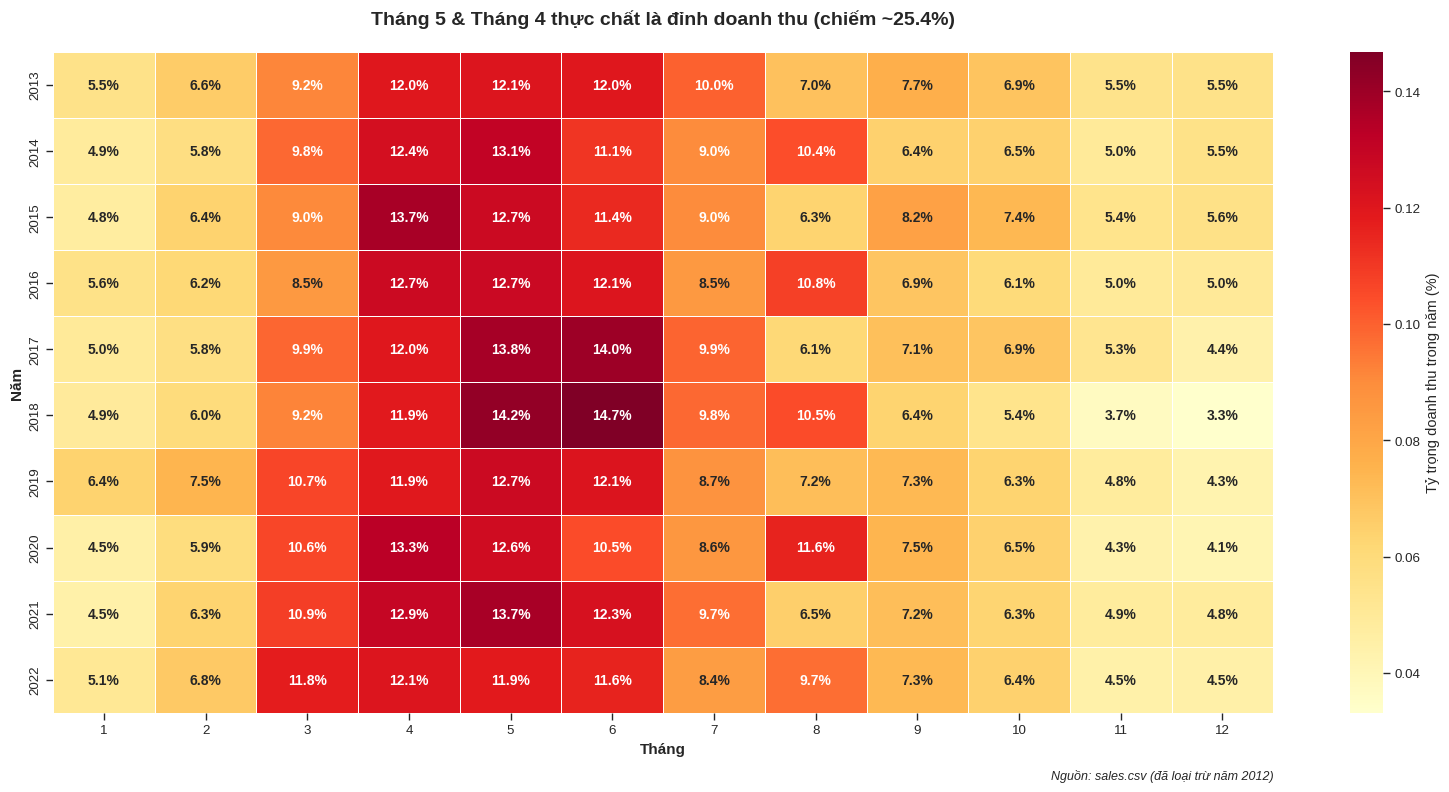

In [33]:
# 1. Ensure Date is datetime before using .dt
df_sales['Date'] = pd.to_datetime(df_sales['Date'], errors='coerce')

# 2. Lọc bỏ năm 2012 vì không đủ 12 tháng (dữ liệu bắt đầu từ 04/07/2012)
df_sales_full_years = df_sales[df_sales['Date'].dt.year > 2012].copy()

df_sales_full_years['month'] = df_sales_full_years['Date'].dt.month
df_sales_full_years['year'] = df_sales_full_years['Date'].dt.year

# 2. Pivot tính tổng doanh thu theo Năm và Tháng
pivot_revenue = df_sales_full_years.groupby(['year', 'month'])['Revenue'].sum().unstack()

# 3. Normalize theo từng năm (row) để thấy tỷ trọng %
pivot_pct = pivot_revenue.div(pivot_revenue.sum(axis=1), axis=0)

# 4. Tìm các tháng có tỷ trọng trung bình cao nhất để tự động điền vào tiêu đề
avg_pct_by_month = pivot_pct.mean()
top_2_months = avg_pct_by_month.nlargest(2)
month_1, month_2 = top_2_months.index[0], top_2_months.index[1]
sum_top_2_pct = top_2_months.sum() * 100

# Khởi tạo Figure
plt.figure(figsize=(16, 8))

# Vẽ heatmap
ax = sns.heatmap(pivot_pct, 
                 cmap='YlOrRd', 
                 annot=True, 
                 fmt='.1%', 
                 linewidths=0.5, 
                 cbar_kws={'label': 'Tỷ trọng doanh thu trong năm (%)'},
                 annot_kws={"size": 10, "weight": "bold"})

# Tiêu đề động dựa trên dữ liệu thực tế sau khi đã lọc
title_str = f"Tháng {month_1} & Tháng {month_2} thực chất là đỉnh doanh thu (chiếm ~{sum_top_2_pct:.1f}%)"
plt.title(title_str, fontsize=14, pad=20, fontweight='bold')

plt.xlabel("Tháng", fontsize=11, fontweight='bold')
plt.ylabel("Năm", fontsize=11, fontweight='bold')

# Cố định lại hiển thị trục X cho đủ 12 tháng
plt.xticks(ticks=[i + 0.5 for i in range(12)], labels=range(1, 13))

plt.annotate('Nguồn: sales.csv (đã loại trừ năm 2012)', xy=(1, -0.1), xycoords='axes fraction', ha='right', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# Theme 3 — Margin × Volume Matrix (Segment Strategy)

## Segmentation
- Phân nhóm sản phẩm:
  - Premium
  - Performance
  - Activewear
  - Standard

In [34]:
df_orders_items.columns = df_orders_items.columns.str.strip()
df_products.columns = df_products.columns.str.strip()

df_merged_items_product = pd.merge(df_orders_items, df_products, on='product_id', how='left')
display(df_merged_items_product.head())

df_merged_items_product['item_margin'] = (
    df_merged_items_product['unit_price'] - df_merged_items_product['cogs']
 ) / df_merged_items_product['unit_price']

segment_analysis = df_merged_items_product.groupby('segment', as_index=False).agg({
    'item_margin': 'mean',
    'product_id': 'count'  
}).rename(columns={'product_id': 'volume', 'item_margin': 'avg_margin'})

print("Dữ liệu phân khúc đã sẵn sàng cho ma trận:")
print(segment_analysis.head(8))

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs
0,1,2400,7,"1,138",0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,"1,109","1,054"
1,2,609,7,"10,166",0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,427","8,988"
2,3,396,3,"11,220",0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028","10,091"
3,4,635,5,"10,639",0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745","9,205"
4,6,1935,1,"1,598",0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,610","1,049"


Dữ liệu phân khúc đã sẵn sàng cho ma trận:
       segment  avg_margin  volume
0   Activewear           0  230375
1  All-weather           0   22570
2     Balanced           0  103333
3     Everyday           0  182533
4  Performance           0   96730
5      Premium           0   31032
6     Standard           0   10937
7       Trendy           0   37159


### Graph 7 - Margin x Volume Matrix

Scatter plot này định vị từng segment theo 2 trục: quy mô bán và biên lợi nhuận trung bình.
Hai đường trung bình dọc-ngang giúp chia quadrant để xác định nhóm cần ưu tiên tăng trưởng hoặc tối ưu margin.

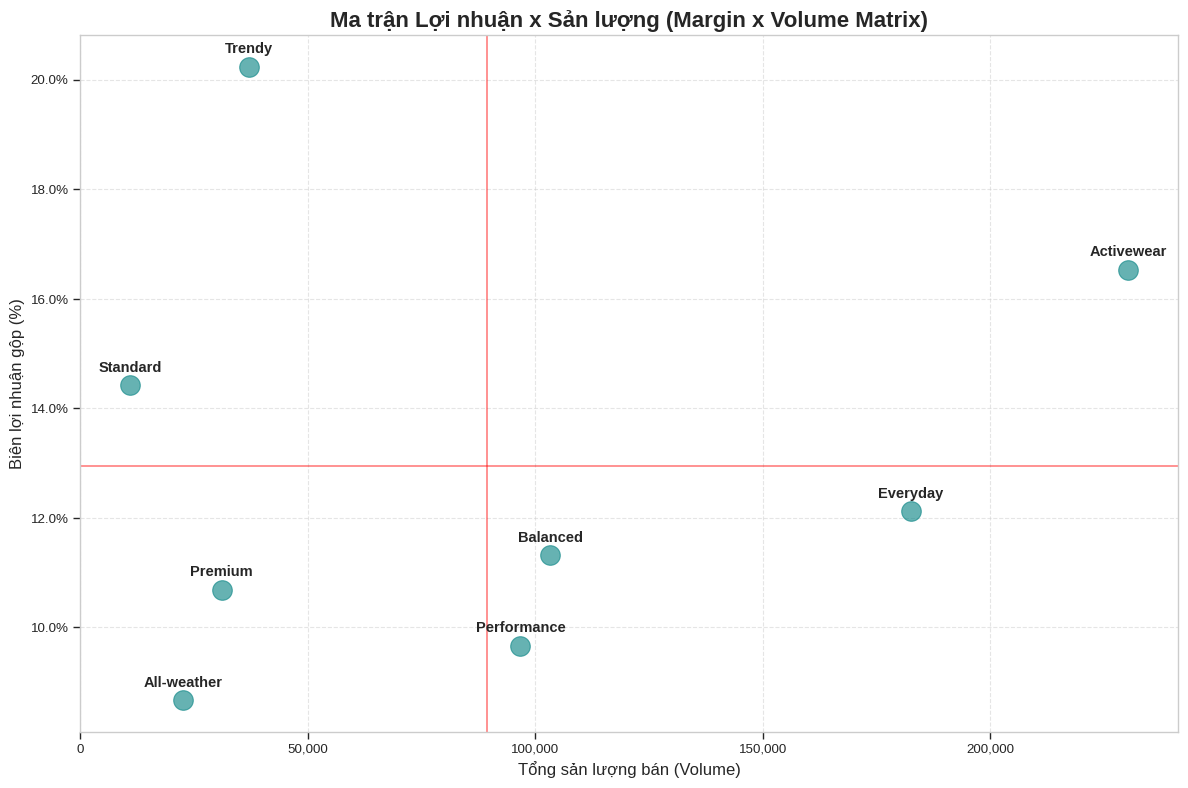

In [35]:
plt.figure(figsize=(12, 8))
plt.scatter(segment_analysis['volume'], segment_analysis['avg_margin'], s=200, c='teal', alpha=0.6)

for i, seg_name in enumerate(segment_analysis['segment']):
    plt.annotate(
        seg_name,
        (segment_analysis['volume'].iloc[i], segment_analysis['avg_margin'].iloc[i]),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontweight='bold',
    )

plt.axvline(segment_analysis['volume'].mean(), color='red', linestyle='-', alpha=0.5)
plt.axhline(segment_analysis['avg_margin'].mean(), color='red', linestyle='-', alpha=0.5)

# Định dạng biểu đồ chuyên nghiệp
plt.title('Ma trận Lợi nhuận x Sản lượng (Margin x Volume Matrix)', fontsize=16, fontweight='bold')
plt.xlabel('Tổng sản lượng bán (Volume)', fontsize=12)
plt.ylabel('Biên lợi nhuận gộp (%)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig_path = OUTPUT_DIR / 'margin_volume_matrix.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [36]:

# ── 1. Load data ─────────────────────────────────────────────────────────────
DATA_DIR = '/home/ducvu0904/Downloads/Datathon/data'
orders = pd.read_csv(f'{DATA_DIR}/orders.csv', skipinitialspace=True)
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv', low_memory=False)
products = pd.read_csv(f'{DATA_DIR}/products.csv')
promotions = pd.read_csv(f'{DATA_DIR}/promotions.csv')
returns = pd.read_csv(f'{DATA_DIR}/returns.csv')

# ── 2. Xác định promo IDs thuộc "Urban Blowout" (các năm lẻ) ─────────────────
ub_promos = promotions[
    promotions['promo_name'].str.contains('Urban Blowout', case=False, na=False)
] .copy()

ub_ids = set(ub_promos['promo_id'].tolist())
print('Urban Blowout promotions found:')
print(
    ub_promos[
        ['promo_id', 'promo_name', 'start_date', 'end_date', 'discount_value', 'promo_type']
    ].to_string(index=False)
 )

# ── 3. Lọc order_items thuộc Urban Blowout ───────────────────────────────────
mask_ub = (
    order_items['promo_id'].isin(ub_ids) |
    order_items['promo_id_2'].isin(ub_ids)
 )
ub_items = order_items[mask_ub].copy()

# ── 4. Merge order metadata ──────────────────────────────────────────────────
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_status'] = orders['order_status'].str.strip().str.lower()

ub_items = ub_items.merge(
    orders[['order_id', 'order_date', 'order_status']],
    on='order_id', how='left'
 )

# ── 5. Chỉ giữ orders hợp lệ (loại cancelled / returned / created) ───────────
valid_statuses = {'delivered', 'paid', 'shipped'}
ub_items = ub_items[ub_items['order_status'].isin(valid_statuses)].copy()

# ── 6. Merge COGS từ bảng products ──────────────────────────────────────────
ub_items = ub_items.merge(
    products[['product_id', 'cogs']],
    on='product_id', how='left'
 )

# ── 7. Tính Revenue & COGS ───────────────────────────────────────────────────
ub_items['revenue'] = (
    ub_items['quantity'] * ub_items['unit_price'] - ub_items['discount_amount']
 )
ub_items['total_cogs'] = ub_items['quantity'] * ub_items['cogs']
ub_items['gross_profit'] = ub_items['revenue'] - ub_items['total_cogs']

# Tag năm của promo (dùng promo_id để map, không dùng order_date vì orders có
# thể trải dài qua năm mới)
promo_year_map = (
    ub_promos.set_index('promo_id')['promo_name']
    .str.extract(r'(\d{4})')[0]
    .astype('Int64')
    .to_dict()
 )
ub_items['promo_year'] = ub_items['promo_id'].map(promo_year_map).fillna(
    ub_items['promo_id_2'].map(promo_year_map)
 ).astype('Int64')

# ── 8. Tính refunds cho các returned orders thuộc UB ─────────────────────────
# Lấy toàn bộ order_ids từ UB items (kể cả returned) để map refund
all_ub_order_ids = order_items[mask_ub]['order_id'].unique()
ub_returns = returns[returns['order_id'].isin(all_ub_order_ids)].copy()

# Map promo_year cho returns qua order_id → promo_id
order_promo_year = (
    order_items[mask_ub][['order_id', 'promo_id', 'promo_id_2']]
    .drop_duplicates('order_id')
    .assign(
        promo_year=lambda df: df['promo_id'].map(promo_year_map).fillna(
            df['promo_id_2'].map(promo_year_map)
        ).astype('Int64')
    )
    [['order_id', 'promo_year']]
 )
ub_returns = ub_returns.merge(order_promo_year, on='order_id', how='left')

refund_by_year = (
    ub_returns.groupby('promo_year')['refund_amount']
    .sum()
    .rename('total_refunds')
 )

# ── 9. Tổng hợp theo năm ─────────────────────────────────────────────────────
summary = (
    ub_items.groupby('promo_year')
    .agg(
        orders_count=('order_id', 'nunique'),
        items_sold=('quantity', 'sum'),
        gross_revenue=('revenue', 'sum'),
        total_cogs=('total_cogs', 'sum'),
        gross_profit=('gross_profit', 'sum'),
    )
    .join(refund_by_year, how='left')
    .fillna({'total_refunds': 0})
 )

summary['net_revenue'] = summary['gross_revenue'] - summary['total_refunds']
summary['net_profit'] = summary['gross_profit'] - summary['total_refunds']
summary['gross_margin_%'] = (
    summary['gross_profit'] / summary['gross_revenue'] * 100
 ).round(2)
summary['net_margin_%'] = (
    summary['net_profit'] / summary['net_revenue'] * 100
 ).round(2)

odd_years = [2013, 2015, 2017, 2019, 2021]
summary = summary.loc[summary.index.isin(odd_years)].sort_index()

# ── 10. In kết quả ──────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('\n' + '=' * 90)
print('URBAN BLOWOUT CAMPAIGN — P&L SUMMARY (Odd Years)')
print('=' * 90)
print(summary.to_string())

print('\n' + '─' * 90)
total = summary[[
    'gross_revenue', 'total_cogs', 'gross_profit',
    'total_refunds', 'net_revenue', 'net_profit'
 ]].sum()
total['gross_margin_%'] = total['gross_profit'] / total['gross_revenue'] * 100
total['net_margin_%'] = total['net_profit'] / total['net_revenue'] * 100
print('GRAND TOTAL (all odd years combined):')
for k, v in total.items():
    print(f'  {k:<20} : {v:>15,.0f}')

print('\nGhi chu:')
print('  gross_revenue   = qty × unit_price − discount_amount (theo tung dong order)')
print('  total_cogs      = qty × cogs (tu products.csv)')
print('  gross_profit    = gross_revenue − total_cogs')
print('  total_refunds   = refund_amount tu returns.csv (only returned orders)')
print('  net_revenue     = gross_revenue − total_refunds')
print('  net_profit      = gross_profit  − total_refunds')
print('  Don vi: VND (hoac currency goc cua dataset)')

col_label_map = {
    'gross_revenue': 'Gross revenue',
    'total_cogs': 'Total cogs',
    'gross_profit': 'Gross profit',
    'total_refunds': 'Total refunds',
    'net_revenue': 'Net revenue',
    'net_profit': 'Net profit',
    'gross_margin_%': 'Gross margin %',
    'net_margin_%': 'Net margin %',
    'orders_count': 'Orders count',
    'items_sold': 'Items sold',
}

# Convert total to dataframe
total_df = pd.DataFrame([total]).rename(columns=col_label_map)
display(total_df)
summary_df = (
    summary
    .reset_index()
    .rename(columns={'promo_year': 'Year', **col_label_map})
 )
display(summary_df)
path_total_df = OUTPUT_DIR / 'urban_blowout_total_summary.csv'
total_df.to_csv(path_total_df, index=False)
path_summary_df = OUTPUT_DIR / 'urban_blowout_yearly_summary.csv'
summary_df.to_csv(path_summary_df, index=False)
print(f"Total summary saved to {path_total_df}")

Urban Blowout promotions found:
  promo_id         promo_name start_date   end_date  discount_value promo_type
PROMO-0005 Urban Blowout 2013 2013-07-30 2013-09-02              50      fixed
PROMO-0015 Urban Blowout 2015 2015-07-30 2015-09-02              50      fixed
PROMO-0025 Urban Blowout 2017 2017-07-30 2017-09-02              50      fixed
PROMO-0035 Urban Blowout 2019 2019-07-30 2019-09-02              50      fixed
PROMO-0045 Urban Blowout 2021 2021-07-30 2021-09-02              50      fixed

URBAN BLOWOUT CAMPAIGN — P&L SUMMARY (Odd Years)
            orders_count  items_sold  gross_revenue  total_cogs  gross_profit  total_refunds  net_revenue  net_profit  gross_margin_%  net_margin_%
promo_year                                                                                                                                         
2013                4040       18452     67,362,886 109,722,014   -42,359,128      2,585,010   64,777,876 -44,944,138             -63           -69


,Gross revenue,Total cogs,Gross profit,Total refunds,Net revenue,Net profit,Gross margin %,Net margin %
0,"317,493,112","514,302,673","-196,809,561","12,044,735","305,448,377","-208,854,296",-62,-68


,Year,Orders count,Items sold,Gross revenue,Total cogs,Gross profit,Total refunds,Net revenue,Net profit,Gross margin %,Net margin %
0,2013,4040,18452,"67,362,886","109,722,014","-42,359,128","2,585,010","64,777,876","-44,944,138",-63,-69
1,2015,4304,19775,"73,434,165","117,965,353","-44,531,188","2,680,050","70,754,116","-47,211,237",-61,-67
2,2017,4512,20615,"79,564,018","128,051,084","-48,487,066","3,369,265","76,194,753","-51,856,331",-61,-68
3,2019,2685,12176,"52,706,951","84,133,660","-31,426,709","1,853,979","50,852,972","-33,280,688",-60,-65
4,2021,1991,9007,"44,425,091","74,430,562","-30,005,471","1,556,430","42,868,661","-31,561,902",-68,-74


Total summary saved to output/urban_blowout_total_summary.csv


In [37]:
import pandas as pd

# Giả sử bạn đã chạy các bước load data: orders, order_items, products, returns
# và đã tạo danh sách ub_ids (chứa các promo_id của Urban Blowout)

# --- BƯỚC 1: XÁC ĐỊNH GIỎ HÀNG MỤC TIÊU ---
# Tìm các đơn hàng CÓ CHỨA sản phẩm Urban Blowout
mask_ub = (order_items['promo_id'].isin(ub_ids) | order_items['promo_id_2'].isin(ub_ids))
orders_with_ub = order_items[mask_ub]['order_id'].unique()

# --- BƯỚC 2: KHÔI PHỤC TOÀN BỘ GIỎ HÀNG ---
# Lấy toàn bộ items (cả UB và đồ nguyên giá) thuộc các đơn hàng trên
basket_items = order_items[order_items['order_id'].isin(orders_with_ub)].copy()

# --- BƯỚC 3: LỌC ĐƠN HÀNG HỢP LỆ & NĂM LẺ (FIX LỖI 1) ---
valid_statuses = {'delivered', 'paid', 'shipped'}
basket_items = basket_items.merge(
    orders[['order_id', 'order_date', 'order_status']], 
    on='order_id', how='left'
)
# Bỏ qua các đơn bị huỷ (cancelled, created,...)
basket_items = basket_items[basket_items['order_status'].isin(valid_statuses)]

# Lọc chỉ lấy các năm lẻ có diễn ra chiến dịch (để khớp con số 208.9M)
basket_items['order_year'] = pd.to_datetime(basket_items['order_date']).dt.year
odd_years = [2013, 2015, 2017, 2019, 2021]
basket_items = basket_items[basket_items['order_year'].isin(odd_years)]

valid_order_ids = basket_items['order_id'].unique()

# --- BƯỚC 4: DÁN NHÃN & TÍNH GROSS PROFIT TỪNG DÒNG ---
basket_items = basket_items.merge(products[['product_id', 'cogs']], on='product_id', how='left')

# Phân loại: Món nào là "Chim mồi" (UB), món nào là "Bán kèm" (Cross-sell)
basket_items['is_ub_promo'] = basket_items['promo_id'].isin(ub_ids) | basket_items['promo_id_2'].isin(ub_ids)
basket_items['item_type'] = basket_items['is_ub_promo'].map({True: 'UB_Promo_Item', False: 'Cross_sell_Item'})

# Tính Gross Profit từng dòng
basket_items['revenue'] = (basket_items['quantity'] * basket_items['unit_price']) - basket_items['discount_amount']
basket_items['total_cogs'] = basket_items['quantity'] * basket_items['cogs']
basket_items['gross_profit'] = basket_items['revenue'] - basket_items['total_cogs']

# --- BƯỚC 5: TỔNG HỢP LỢI NHUẬN CẤP ĐỘ ĐƠN HÀNG (PIVOT) ---
order_profitability = basket_items.pivot_table(
    index='order_id', 
    columns='item_type', 
    values='gross_profit', 
    aggfunc='sum',
    fill_value=0
).reset_index()

# Đảm bảo dataframe có đủ 2 cột (trường hợp khách ko mua cross-sell món nào)
if 'Cross_sell_Item' not in order_profitability.columns:
    order_profitability['Cross_sell_Item'] = 0

order_profitability['Total_Gross_Profit'] = order_profitability['UB_Promo_Item'] + order_profitability['Cross_sell_Item']

# --- BƯỚC 6: TRỪ TIỀN HOÀN TRẢ ĐỂ TÍNH NET PROFIT (FIX LỖI 2) ---
# Lấy dữ liệu return của các giỏ hàng này
basket_returns = returns[returns['order_id'].isin(valid_order_ids)].copy()
refund_by_order = basket_returns.groupby('order_id')['refund_amount'].sum().reset_index()

# Merge tiền refund vào bảng lợi nhuận đơn hàng
order_profitability = order_profitability.merge(refund_by_order, on='order_id', how='left')
order_profitability['refund_amount'] = order_profitability['refund_amount'].fillna(0)

# Tính Net Profit thực tế (Chốt hạ)
order_profitability['Total_Net_Profit'] = order_profitability['Total_Gross_Profit'] - order_profitability['refund_amount']

# --- BƯỚC 7: KẾT LUẬN CHIẾN LƯỢC ---
profitable_baskets = order_profitability[order_profitability['Total_Net_Profit'] > 0]
loss_baskets = order_profitability[order_profitability['Total_Net_Profit'] <= 0]

total_orders = len(order_profitability)
win_rate = (len(profitable_baskets) / total_orders * 100) if total_orders > 0 else 0

print("\n" + "="*60)
print("PHÂN TÍCH GIỎ HÀNG: CHIM MỒI HAY BỊ 'BÀO' SALE?")
print("="*60)
print(f"Tổng số giỏ hàng CÓ CHỨA đồ Urban Blowout (Đơn hợp lệ): {total_orders:,.0f}")
print(f"Số giỏ hàng GÁNH LỖ THÀNH CÔNG (Net Profit > 0): {len(profitable_baskets):,.0f} ({win_rate:.1f}%)")
print(f"Số giỏ hàng BỊ KHÁCH 'BÀO' (Net Profit <= 0): {len(loss_baskets):,.0f} ({(100-win_rate):.1f}%)")

total_promo_gross = order_profitability['UB_Promo_Item'].sum()
total_cross_sell_gross = order_profitability['Cross_sell_Item'].sum()
total_refunds = order_profitability['refund_amount'].sum()
net_campaign_impact = order_profitability['Total_Net_Profit'].sum()

print("\n--- TỔNG KẾT P&L CẤP ĐỘ GIỎ HÀNG ---")
print(f"1. Lãi/Lỗ gộp từ đồ xả lỗ (UB Promo) : {total_promo_gross:>15,.0f} VNĐ")
print(f"2. Lãi/Lỗ gộp kéo lại từ Cross-sell  : {total_cross_sell_gross:>15,.0f} VNĐ")
print(f"3. Bị trừ do khách hàng Hoàn trả     : {-total_refunds:>15,.0f} VNĐ")
print("-" * 50)
print(f"TỔNG NET PROFIT THỰC TẾ (Net Impact) : {net_campaign_impact:>15,.0f} VNĐ")


PHÂN TÍCH GIỎ HÀNG: CHIM MỒI HAY BỊ 'BÀO' SALE?
Tổng số giỏ hàng CÓ CHỨA đồ Urban Blowout (Đơn hợp lệ): 17,532
Số giỏ hàng GÁNH LỖ THÀNH CÔNG (Net Profit > 0): 121 (0.7%)
Số giỏ hàng BỊ KHÁCH 'BÀO' (Net Profit <= 0): 17,411 (99.3%)

--- TỔNG KẾT P&L CẤP ĐỘ GIỎ HÀNG ---
1. Lãi/Lỗ gộp từ đồ xả lỗ (UB Promo) :    -196,809,561 VNĐ
2. Lãi/Lỗ gộp kéo lại từ Cross-sell  :         437,310 VNĐ
3. Bị trừ do khách hàng Hoàn trả     :              -0 VNĐ
--------------------------------------------------
TỔNG NET PROFIT THỰC TẾ (Net Impact) :    -196,372,251 VNĐ


In [48]:
# Urban Blowout size and color ranking
ub_items_with_attr = ub_items.merge(
    products[['product_id', 'size', 'color', 'cogs']],
    on='product_id',
    how='left'
)

if 'revenue' not in ub_items_with_attr.columns:
    ub_items_with_attr['revenue'] = (
        ub_items_with_attr['quantity'] * ub_items_with_attr['unit_price']
        - ub_items_with_attr['discount_amount']
    )

if 'total_cogs' not in ub_items_with_attr.columns:
    ub_items_with_attr['total_cogs'] = ub_items_with_attr['quantity'] * ub_items_with_attr['cogs']
if 'gross_profit' not in ub_items_with_attr.columns:
    ub_items_with_attr['gross_profit'] = (
        ub_items_with_attr['revenue'] - ub_items_with_attr['total_cogs']
    )

ub_items_with_attr['size'] = ub_items_with_attr['size'].fillna('Unknown')
ub_items_with_attr['color'] = ub_items_with_attr['color'].fillna('Unknown')

size_rank = (
    ub_items_with_attr.groupby('size', as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        items_sold=('quantity', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        total_gross_loss=('gross_profit', lambda x: x[x < 0].sum()),
    )
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)
size_rank['gross_margin_%'] = (
    size_rank['gross_profit'] / size_rank['revenue'] * 100
).round(0).fillna(0).astype('int64')
size_rank['revenue'] = size_rank['revenue'].round(0).astype('int64')
size_rank['items_sold'] = size_rank['items_sold'].round(0).astype('int64')
size_rank['total_gross_loss'] = size_rank['total_gross_loss'].round(0).astype('int64')
size_rank = size_rank.drop(columns=['gross_profit'])
size_rank.insert(0, 'rank', range(1, len(size_rank) + 1))
size_rank = size_rank.rename(columns={
    'size': 'Size',
    'revenue': 'Revenue',
    'items_sold': 'Items sold',
    'gross_margin_%': 'Gross margin %',
    'total_gross_loss': 'Total gross loss',
    'rank': 'Rank',
})

color_rank = (
    ub_items_with_attr.groupby('color', as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        items_sold=('quantity', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        total_gross_loss=('gross_profit', lambda x: x[x < 0].sum()),
    )
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)
color_rank['gross_margin_%'] = (
    color_rank['gross_profit'] / color_rank['revenue'] * 100
).round(0).fillna(0).astype('int64')
color_rank['revenue'] = color_rank['revenue'].round(0).astype('int64')
color_rank['items_sold'] = color_rank['items_sold'].round(0).astype('int64')
color_rank['total_gross_loss'] = color_rank['total_gross_loss'].round(0).astype('int64')
color_rank = color_rank.drop(columns=['gross_profit'])
color_rank.insert(0, 'rank', range(1, len(color_rank) + 1))
color_rank = color_rank.rename(columns={
    'color': 'Color',
    'revenue': 'Revenue',
    'items_sold': 'Items sold',
    'gross_margin_%': 'Gross margin %',
    'total_gross_loss': 'Total gross loss',
    'rank': 'Rank',
})

print('Top sizes by revenue:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(size_rank)

print('Top colors by revenue:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(color_rank)

Top sizes by revenue:


,Rank,Size,Revenue,Items sold,Total gross loss,Gross margin %
0,1,XL,124641356,28869,-83873070,-67
1,2,L,86119135,21382,-52801203,-61
2,3,S,85970718,23420,-52244378,-61
3,4,M,80677271,21695,-46754525,-58


Top colors by revenue:


,Rank,Color,Revenue,Items sold,Total gross loss,Gross margin %
0,1,green,57508604,12777,-42707559,-74
1,2,silver,51868705,11758,-34871270,-67
2,3,purple,49221520,12290,-27821918,-56
3,4,black,39762420,10244,-30628982,-77
4,5,yellow,39480465,9247,-25150900,-64
5,6,white,32745523,9543,-18818246,-57
6,7,red,28828021,7770,-16570370,-57
7,8,orange,28139475,8752,-18183529,-65
8,9,blue,24985517,7025,-12154525,-49
9,10,pink,24868230,5960,-8765878,-35


In [50]:
# Urban Blowout segment ranking
ub_items_with_segment = ub_items.merge(
    products[['product_id', 'segment', 'cogs']],
    on='product_id',
    how='left'
)

if 'revenue' not in ub_items_with_segment.columns:
    ub_items_with_segment['revenue'] = (
        ub_items_with_segment['quantity'] * ub_items_with_segment['unit_price']
        - ub_items_with_segment['discount_amount']
    )

if 'total_cogs' not in ub_items_with_segment.columns:
    ub_items_with_segment['total_cogs'] = ub_items_with_segment['quantity'] * ub_items_with_segment['cogs']
if 'gross_profit' not in ub_items_with_segment.columns:
    ub_items_with_segment['gross_profit'] = (
        ub_items_with_segment['revenue'] - ub_items_with_segment['total_cogs']
    )

ub_items_with_segment['segment'] = ub_items_with_segment['segment'].fillna('Unknown')

segment_rank = (
    ub_items_with_segment.groupby('segment', as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        items_sold=('quantity', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        total_gross_loss=('gross_profit', lambda x: x[x < 0].sum()),
    )
    .sort_values('revenue', ascending=False)
    .reset_index(drop=True)
)
segment_rank['gross_margin_%'] = (
    segment_rank['gross_profit'] / segment_rank['revenue'] * 100
).round(0).fillna(0).astype('int64')
segment_rank['revenue'] = segment_rank['revenue'].round(0).astype('int64')
segment_rank['items_sold'] = segment_rank['items_sold'].round(0).astype('int64')
segment_rank['total_gross_loss'] = segment_rank['total_gross_loss'].round(0).astype('int64')
segment_rank = segment_rank.drop(columns=['gross_profit'])
segment_rank.insert(0, 'rank', range(1, len(segment_rank) + 1))
segment_rank = segment_rank.rename(columns={
    'segment': 'Segment',
    'revenue': 'Revenue',
    'items_sold': 'Items sold',
    'gross_margin_%': 'Gross margin %',
    'total_gross_loss': 'Total gross loss',
    'rank': 'Rank',
})

print('Top segments by revenue:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(segment_rank)

Top segments by revenue:


,Rank,Segment,Revenue,Items sold,Total gross loss,Gross margin %
0,1,Everyday,155905905,45223,-94765585,-61
1,2,Balanced,149235587,24957,-93996377,-63
2,3,Performance,64746711,22336,-42759160,-66
3,4,Standard,7520277,2850,-4152054,-55


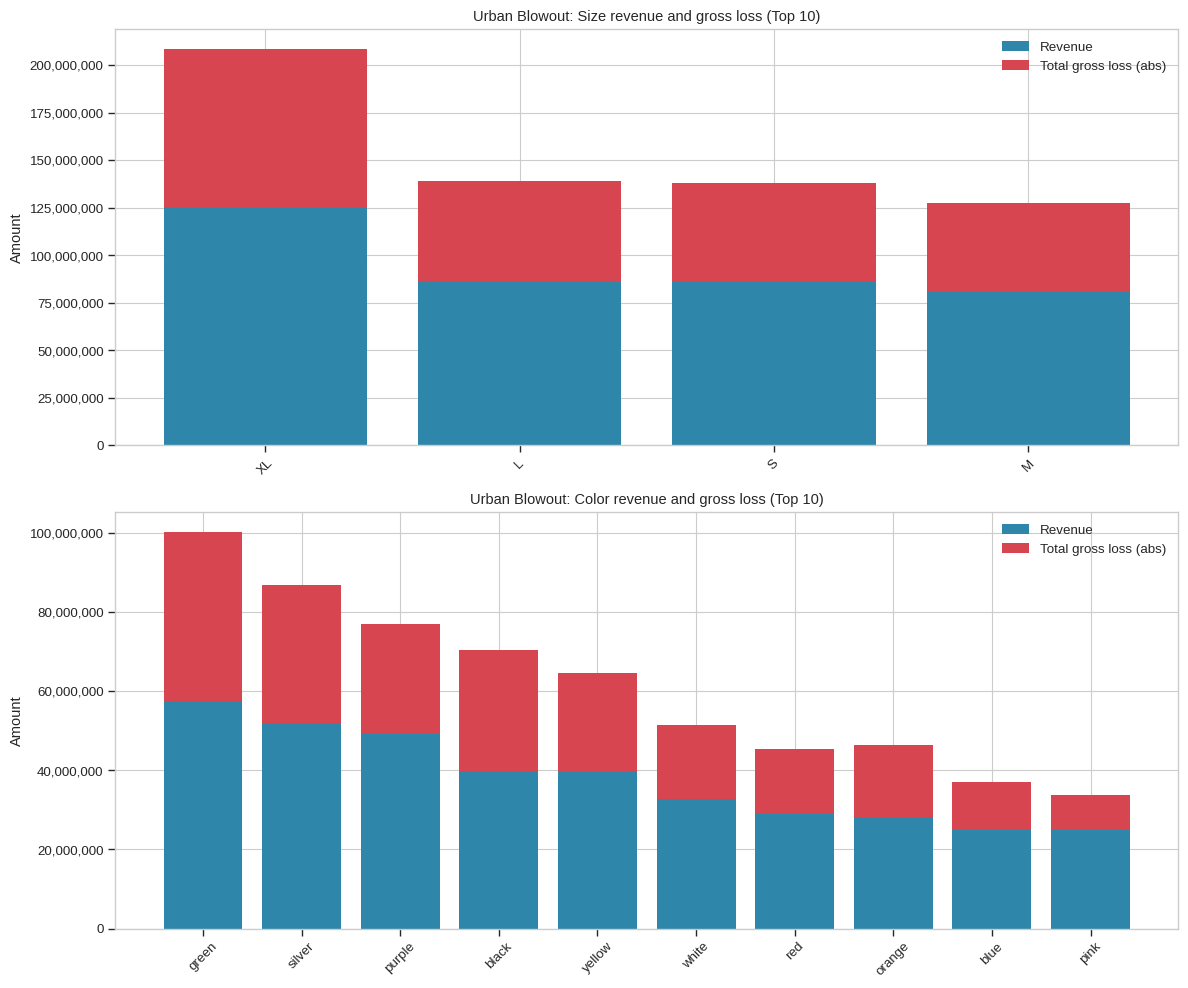

In [49]:
# Stacked bar plots for size and color (top 10 by revenue)
plot_sizes = size_rank.head(10).copy()
plot_sizes['Loss abs'] = plot_sizes['Total gross loss'].abs()

plot_colors = color_rank.head(10).copy()
plot_colors['Loss abs'] = plot_colors['Total gross loss'].abs()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

axes[0].bar(plot_sizes['Size'], plot_sizes['Revenue'], label='Revenue', color='#2E86AB')
axes[0].bar(
    plot_sizes['Size'],
    plot_sizes['Loss abs'],
    bottom=plot_sizes['Revenue'],
    label='Total gross loss (abs)',
    color='#D64550'
)
axes[0].set_title('Urban Blowout: Size revenue and gross loss (Top 10)')
axes[0].set_ylabel('Amount')
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

axes[1].bar(plot_colors['Color'], plot_colors['Revenue'], label='Revenue', color='#2E86AB')
axes[1].bar(
    plot_colors['Color'],
    plot_colors['Loss abs'],
    bottom=plot_colors['Revenue'],
    label='Total gross loss (abs)',
    color='#D64550'
)
axes[1].set_title('Urban Blowout: Color revenue and gross loss (Top 10)')
axes[1].set_ylabel('Amount')
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

,year,units_received,units_sold
0,2013,35182,29907
1,2015,41269,35031
2,2017,43840,37208
3,2019,23662,20211
4,2021,20603,17648


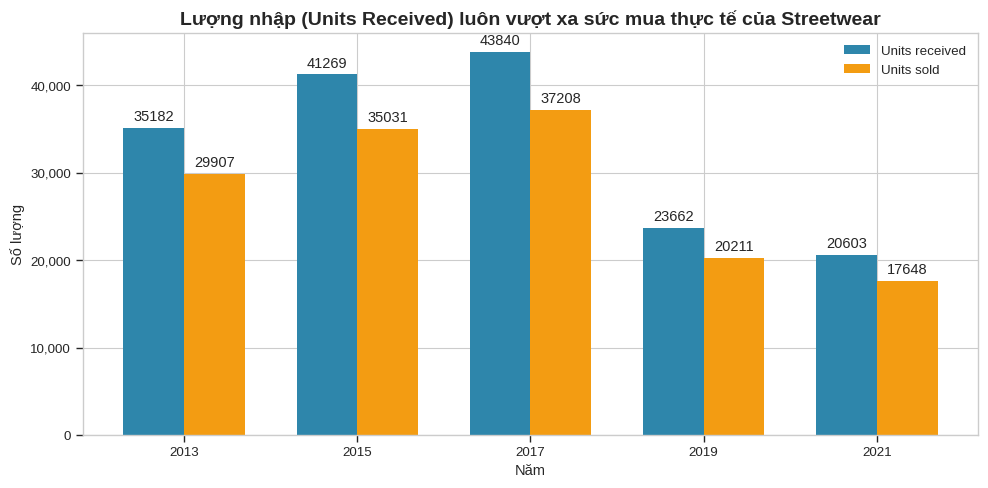

In [57]:
# Streetwear units received vs sold (Jan-Jun, odd years)
inventory_path = (
    f"{DATA_DIR}/inventory.csv" if 'DATA_DIR' in globals()
    else '/home/ducvu0904/Downloads/Datathon/data/inventory.csv'
 )
df_inventory = pd.read_csv(inventory_path)

df_inventory['year'] = df_inventory['year'].astype(int)
df_inventory['month'] = df_inventory['month'].astype(int)

streetwear = df_inventory[
    (df_inventory['category'] == 'Streetwear')
    & (df_inventory['month'].between(1, 6))
    & (df_inventory['year'] % 2 == 1)
].copy()

if streetwear.empty:
    print('No Streetwear data found for Jan-Jun in odd years.')
else:
    streetwear_summary = (
        streetwear.groupby('year', as_index=False)[['units_received', 'units_sold']]
        .sum()
        .sort_values('year')
    )
    display(streetwear_summary)

    x = np.arange(len(streetwear_summary))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars_received = ax.bar(
        x - width / 2,
        streetwear_summary['units_received'],
        width,
        label='Units received',
        color='#2E86AB',
    )
    bars_sold = ax.bar(
        x + width / 2,
        streetwear_summary['units_sold'],
        width,
        label='Units sold',
        color='#F39C12',
    )

    ax.bar_label(bars_received, padding=3, fmt='%.0f')
    ax.bar_label(bars_sold, padding=3, fmt='%.0f')

    ax.set_title('Lượng nhập (Units Received) luôn vượt xa sức mua thực tế của Streetwear', fontsize=14, fontweight='bold')
    ax.set_xlabel('Năm')
    ax.set_ylabel('Số lượng')
    ax.set_xticks(x, streetwear_summary['year'])
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Margin vs volume scatter plot by segment (exclude Streetwear)
if 'df_products' in globals():
    products_df = df_products.copy()
elif 'products' in globals():
    products_df = products.copy()
else:
    products_path = (
        f"{DATA_DIR}/products.csv" if 'DATA_DIR' in globals()
        else '/home/ducvu0904/Downloads/Datathon/data/products.csv'
    )
    products_df = pd.read_csv(products_path)

if 'df_orders_items' in globals():
    items_df = df_orders_items.copy()
elif 'order_items' in globals():
    items_df = order_items.copy()
else:
    items_path = (
        f"{DATA_DIR}/order_items.csv" if 'DATA_DIR' in globals()
        else '/home/ducvu0904/Downloads/Datathon/data/order_items.csv'
    )
    items_df = pd.read_csv(items_path, low_memory=False)

products_filtered = products_df.copy()
products_filtered['category'] = products_filtered['category'].fillna('')
products_filtered = products_filtered[
    products_filtered['category'].str.strip().str.lower() != 'streetwear'
].copy()

segment_items = items_df.merge(
    products_filtered[['product_id', 'segment', 'cogs']],
    on='product_id',
    how='inner',
 )
segment_items['segment'] = segment_items['segment'].fillna('Unknown')
if 'discount_amount' not in segment_items.columns:
    segment_items['discount_amount'] = 0

segment_items['revenue'] = (
    segment_items['quantity'] * segment_items['unit_price']
    - segment_items['discount_amount']
 )
segment_items['total_cogs'] = segment_items['quantity'] * segment_items['cogs']
segment_items['gross_profit'] = segment_items['revenue'] - segment_items['total_cogs']

segment_scatter = (
    segment_items.groupby('segment', as_index=False)
    .agg(
        items_sold=('quantity', 'sum'),
        revenue=('revenue', 'sum'),
        gross_profit=('gross_profit', 'sum'),
    )
 )
segment_scatter = segment_scatter[segment_scatter['revenue'] != 0].copy()
segment_scatter['gross_margin_%'] = (
    segment_scatter['gross_profit'] / segment_scatter['revenue'] * 100
 ).round(1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    segment_scatter['items_sold'],
    segment_scatter['gross_margin_%'],
    s=80,
    color='#2E86AB',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.7,
 )

for _, row in segment_scatter.iterrows():
    ax.annotate(
        row['segment'],
        (row['items_sold'], row['gross_margin_%']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_title('Margin vs volume by segment (excluding Streetwear)')
ax.set_xlabel('Items sold (volume)')
ax.set_ylabel('Gross margin (%)')
ax.axhline(0, color='#666666', linestyle='--', linewidth=1, alpha=0.5)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()